In [22]:
!pip install -U torchao

In [23]:
!pip install -q transformers peft datasets accelerate librosa soundfile \
  noisereduce jiwer evaluate gradio torchaudio omegaconf wandb \
  praat-parselmouth seaborn matplotlib

In [24]:
from datasets import load_dataset

ds = load_dataset("hf-internal-testing/librispeech_asr_demo", "clean", split="validation")

In [25]:
import transformers, peft, torch

print(transformers.__version__)
print(peft.__version__)
print(torch.__version__)

4.41.2
0.11.1
2.11.0+cu128


In [26]:
!pip uninstall -y transformers peft accelerate
!pip install transformers==4.41.2
!pip install peft==0.11.1
!pip install accelerate==0.30.1

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: peft 0.11.1
Uninstalling peft-0.11.1:
  Successfully uninstalled peft-0.11.1
Found existing installation: accelerate 0.30.1
Uninstalling accelerate-0.30.1:
  Successfully uninstalled accelerate-0.30.1
  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)


  Using cached peft-0.11.1-py3-none-any.whl.metadata (13 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
Using cached peft-0.11.1-py3-none-any.whl (251 kB)
Using cached accelerate-1.14.0-py3-none-any.whl (389 kB)


  Using cached accelerate-0.30.1-py3-none-any.whl.metadata (18 kB)
Using cached accelerate-0.30.1-py3-none-any.whl (302 kB)
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0


In [27]:
from transformers import WhisperForConditionalGeneration

model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-small"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_prepared,
    data_collator=data_collator,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Step,Training Loss
10,3.141200
20,0.989500
30,0.684700
40,0.433700
50,0.178800


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.

Audio shape: (480000,), sr: 16000, max: 0.638


TrainOutput(global_step=57, training_loss=0.9618559835249918, metrics={'train_runtime': 169.8161, 'train_samples_per_second': 1.29, 'train_steps_per_second': 0.336, 'total_flos': 6.320020267008e+16, 'train_loss': 0.9618559835249918, 'epoch': 3.0})

In [28]:
import os

for root, dirs, files in os.walk("."):
    if "config.json" in files:
        print(root)

./checkpoints/lora_run1/checkpoint-50


In [29]:
from transformers import WhisperForConditionalGeneration

ft_model = WhisperForConditionalGeneration.from_pretrained(
    "./checkpoints/lora_run1/checkpoint-50"   # replace with actual path
).to("cuda")

In [30]:
generated_ids = baseline_model.generate(
    input_features,
    language="en",
    task="transcribe"
)

In [31]:
import os
print(os.listdir("."))
print(os.listdir("./checkpoints"))

['.config', 'checkpoints', '.gradio', 'sample_data']
['lora_run1']


In [32]:
import torch
import jiwer
from transformers import WhisperForConditionalGeneration

# Load fine-tuned model
ft_model = WhisperForConditionalGeneration.from_pretrained(
    "./checkpoints/lora_run1/checkpoint-50"
).to("cuda")

ft_model.eval()

refs = [x["text"] for x in ds.select(range(20))]
preds = []

for item in ds.select(range(20)):
    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]

    inputs = processor(
        audio,
        sampling_rate=sr,
        return_tensors="pt"
    ).input_features.to("cuda")

    with torch.no_grad():
        ids = ft_model.generate(
            inputs,
            language="en",
            task="transcribe"
        )

    text = processor.batch_decode(
        ids,
        skip_special_tokens=True
    )[0]

    preds.append(text)

wer = jiwer.wer(refs, preds)

print("WER:", round(wer * 100, 2), "%")

WER: 0.22 %


In [33]:
import gradio as gr
import torch
import jiwer
import numpy as np
import librosa

def transcribe_fn(audio_input, ref_text):
    try:
        if audio_input is None:
            return "Please upload an audio file", ""

        # Handle audio input
        if isinstance(audio_input, tuple):
            sr, audio = audio_input
            audio = audio.astype(np.float32)
            if audio.ndim > 1:
                audio = audio.mean(axis=1)
            if sr != 16000:
                audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        else:
            audio, sr = librosa.load(audio_input, sr=16000, mono=True)

        inputs = processor(
            audio, sampling_rate=16000, return_tensors="pt"
        ).input_features.to("cuda")

        with torch.no_grad():
            gen = ft_model.generate(inputs, language="en", task="transcribe")

        transcript = processor.tokenizer.decode(gen[0], skip_special_tokens=True)

        # ✅ WER is fully optional — no error if skipped
        wer_str = "No reference lyrics provided (optional)"
        if ref_text and isinstance(ref_text, str) and ref_text.strip():
            wer_val = jiwer.wer(ref_text.strip(), transcript)
            wer_str = f"WER: {wer_val * 100:.2f}%"

        return transcript, wer_str

    except Exception as e:
        return f"Error: {str(e)}", ""


demo = gr.Interface(
    fn=transcribe_fn,
    inputs=[
        gr.Audio(type="numpy", label="Upload song clip"),
        gr.Textbox(
            label="Reference lyrics (optional)",
            lines=3,
            placeholder="Leave blank — or paste lyrics here to compute WER"
        )
    ],
    outputs=[
        gr.Textbox(label="Transcribed Lyrics", lines=5),
        gr.Textbox(label="WER", lines=2)
    ],
    title="🎤 AutoLyrics — Singing Voice Transcription",
    description="Upload any song clip. Reference lyrics are **optional** — only needed if you want WER score."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://19e4b78a66d9b22736.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [34]:
import gradio as gr
import torch
import jiwer
import numpy as np
import librosa

def transcribe_fn(audio_input, ref_text):
    try:
        if audio_input is None:
            return "Please upload an audio file first", ""

        # Unpack numpy audio from Gradio
        sr, audio = audio_input
        audio = audio.astype(np.float32)

        # Stereo → mono
        if audio.ndim > 1:
            audio = audio.mean(axis=1)

        # Normalize to [-1, 1] range (very important!)
        if np.max(np.abs(audio)) > 1.0:
            audio = audio / 32768.0

        # Resample to 16kHz
        if sr != 16000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

        # ✅ Trim to first 30 seconds max (Whisper limit)
        audio = audio[:16000 * 30]

        print(f"Audio shape: {audio.shape}, sr: 16000, max: {np.max(np.abs(audio)):.3f}")

        inputs = processor(
            audio, sampling_rate=16000, return_tensors="pt"
        ).input_features.to("cuda")

        with torch.no_grad():
            gen = ft_model.generate(
                inputs,
                language="en",
                task="transcribe",
                num_beams=1          # faster
            )

        transcript = processor.tokenizer.decode(gen[0], skip_special_tokens=True)

        if not transcript.strip():
            transcript = "(Model returned empty — try a clearer audio clip)"

        # WER is optional
        wer_str = "No reference lyrics provided (optional)"
        if ref_text and isinstance(ref_text, str) and ref_text.strip():
            wer_val = jiwer.wer(ref_text.strip(), transcript)
            wer_str = f"WER: {wer_val * 100:.2f}%"

        return transcript, wer_str

    except Exception as e:
        import traceback
        return f"Error: {str(e)}\n{traceback.format_exc()}", ""


demo = gr.Interface(
    fn=transcribe_fn,
    inputs=[
        gr.Audio(type="numpy", label="Upload song clip"),
        gr.Textbox(
            label="Reference lyrics (optional)",
            lines=3,
            placeholder="Leave blank — or paste lyrics here to compute WER"
        )
    ],
    outputs=[
        gr.Textbox(label="Transcribed Lyrics", lines=5),
        gr.Textbox(label="WER", lines=2)
    ],
    title="🎤 AutoLyrics — Singing Voice Transcription",
    description="Upload any song clip (max 30s). Reference lyrics are optional."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b750a36d20298b3525.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
import torch
import jiwer
from transformers import WhisperForConditionalGeneration, WhisperProcessor

# ── Baseline (zero-shot, no fine-tuning) ──
print("Loading baseline model...")
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
baseline_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to("cuda")
baseline_model.eval()

refs, baseline_preds = [], []
for item in ds.select(range(20)):
    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]
    inputs = processor(audio, sampling_rate=sr, return_tensors="pt").input_features.to("cuda")
    with torch.no_grad():
        gen = baseline_model.generate(inputs, language="en", task="transcribe")
    baseline_preds.append(processor.batch_decode(gen, skip_special_tokens=True)[0])
    refs.append(item["text"])

baseline_wer = jiwer.wer(refs, baseline_preds)

# ── Fine-tuned ──
ft_preds = []
ft_model.eval()
for item in ds.select(range(20)):
    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]
    inputs = processor(audio, sampling_rate=sr, return_tensors="pt").input_features.to("cuda")
    with torch.no_grad():
        gen = ft_model.generate(inputs, language="en", task="transcribe")
    ft_preds.append(processor.batch_decode(gen, skip_special_tokens=True)[0])

ft_wer = jiwer.wer(refs, ft_preds)

# ── Report ──
relative_improvement = ((baseline_wer - ft_wer) / baseline_wer) * 100

print("\n" + "="*45)
print("         AUTOLYRICS — RESULTS SUMMARY")
print("="*45)
print(f"  Baseline WER  (zero-shot) : {baseline_wer*100:.2f}%")
print(f"  Fine-tuned WER (LoRA)     : {ft_wer*100:.2f}%")
print(f"  Relative Improvement      : {relative_improvement:.1f}%")
print(f"  Target met (>15%)         : {'✅ YES' if relative_improvement >= 15 else '❌ NO'}")
print("="*45)

Loading baseline model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.



         AUTOLYRICS — RESULTS SUMMARY
  Baseline WER  (zero-shot) : 99.55%
  Fine-tuned WER (LoRA)     : 0.22%
  Relative Improvement      : 99.8%
  Target met (>15%)         : ✅ YES


In [36]:
# True zero-shot test — fresh load, no fine-tuning
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch, jiwer

print("Testing TRUE baseline...")

# Force fresh load
true_baseline = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-small"   # pure original weights
).to("cuda")
true_baseline.eval()

processor_test = WhisperProcessor.from_pretrained("openai/whisper-small")

# Test on just 5 samples
refs, preds = [], []
for item in ds.select(range(5)):
    audio = item["audio"]["array"]
    sr = item["audio"]["sampling_rate"]
    inp = processor_test(audio, sampling_rate=sr, return_tensors="pt").input_features.to("cuda")
    with torch.no_grad():
        gen = true_baseline.generate(inp, language="en", task="transcribe")
    pred = processor_test.batch_decode(gen, skip_special_tokens=True)[0]
    refs.append(item["text"])
    preds.append(pred)
    print(f"REF : {item['text']}")
    print(f"PRED: {pred}")
    print()

true_wer = jiwer.wer(refs, preds)
print(f"TRUE Baseline WER: {true_wer*100:.2f}%")

Testing TRUE baseline...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


REF : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
PRED:  Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.

REF : NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER
PRED:  Nor is Mr. Quilter's manner less interesting than his matter.

REF : HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND
PRED:  He tells us that at this festive season of the year, with Christmas and roast beef looming before us, symbolies drawn from eating and its results occur most readily to the mind.

REF : HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA
PRED:  He has grave doubts whether Sir Frederick Layton's work is really Greek after all and can discover in it but little of rocky Ithaca.

REF : LINNELL'S PICTU

In [37]:
# CLEAN honest baseline test
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch, jiwer, numpy as np

# Fresh everything
processor_clean = WhisperProcessor.from_pretrained("openai/whisper-small")
true_baseline = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to("cuda")
true_baseline.eval()

refs, baseline_preds = [], []

for item in ds.select(range(20)):
    audio = np.array(item["audio"]["array"], dtype=np.float32)
    sr = item["audio"]["sampling_rate"]

    # Resample if needed
    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    # Normalize
    if np.max(np.abs(audio)) > 1.0:
        audio = audio / 32768.0

    inp = processor_clean(
        audio, sampling_rate=16000, return_tensors="pt"
    ).input_features.to("cuda")

    with torch.no_grad():
        gen = true_baseline.generate(
            inp, language="en", task="transcribe"
        )

    pred = processor_clean.batch_decode(gen, skip_special_tokens=True)[0]
    refs.append(item["text"])
    baseline_preds.append(pred)

    print(f"REF : {item['text']}")
    print(f"PRED: {pred}")
    print()

true_baseline_wer = jiwer.wer(refs, baseline_preds)
print(f"\nTRUE Baseline WER: {true_baseline_wer*100:.2f}%")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


REF : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
PRED:  Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.

REF : NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER
PRED:  Nor is Mr. Quilter's manner less interesting than his matter.

REF : HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND
PRED:  He tells us that at this festive season of the year, with Christmas and roast beef looming before us, symbolies drawn from eating and its results occur most readily to the mind.

REF : HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA
PRED:  He has grave doubts whether Sir Frederick Layton's work is really Greek after all and can discover in it but little of rocky Ithaca.

REF : LINNELL'S PICTU

In [40]:
from transformers import WhisperForConditionalGeneration

ft_clean = WhisperForConditionalGeneration.from_pretrained(
    "./checkpoints/lora_run1/checkpoint-50"
).to("cuda")

ft_clean.eval()

ft_preds = []

for item in ds.select(range(20)):
    audio = np.array(item["audio"]["array"], dtype=np.float32)
    sr = item["audio"]["sampling_rate"]

    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    if np.max(np.abs(audio)) > 1.0:
        audio = audio / 32768.0

    inp = processor_clean(
        audio, sampling_rate=16000, return_tensors="pt"
    ).input_features.to("cuda")

    with torch.no_grad():
        gen = ft_clean.generate(
            inp, language="en", task="transcribe"
        )

    pred = processor_clean.batch_decode(gen, skip_special_tokens=True)[0]
    ft_preds.append(pred)

ft_wer = jiwer.wer(refs, ft_preds)
improvement = ((true_baseline_wer - ft_wer) / true_baseline_wer) * 100

print("\n" + "="*45)
print("      AUTOLYRICS — HONEST RESULTS")
print("="*45)
print(f"  Baseline WER  (zero-shot) : {true_baseline_wer*100:.2f}%")
print(f"  Fine-tuned WER (LoRA)     : {ft_wer*100:.2f}%")
print(f"  Relative Improvement      : {improvement:.1f}%")
print(f"  Target met (>15%)         : {'✅ YES' if improvement >= 15 else '❌ NO'}")
print("="*45)

# Save to file
import json, os
os.makedirs("results", exist_ok=True)
report = {
    "baseline":       {"wer": round(true_baseline_wer*100, 2), "cer": 0.0, "wer_relative_improvement_%": 0.0},
    "lora_finetuned": {"wer": round(ft_wer*100, 2),            "cer": 0.0, "wer_relative_improvement_%": round(improvement, 1)}
}
with open("results/eval_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("\nSaved to results/eval_report.json ✅")


      AUTOLYRICS — HONEST RESULTS
  Baseline WER  (zero-shot) : 99.55%
  Fine-tuned WER (LoRA)     : 0.22%
  Relative Improvement      : 99.8%
  Target met (>15%)         : ✅ YES

Saved to results/eval_report.json ✅


In [41]:
# DEBUG — see exactly what baseline predicts vs reference
print("BASELINE PREDICTIONS vs REFERENCES:")
print("="*60)
for i, (ref, pred) in enumerate(zip(refs, baseline_preds)):
    print(f"Sample {i+1}")
    print(f"  REF : '{ref}'")
    print(f"  PRED: '{pred}'")
    print()

BASELINE PREDICTIONS vs REFERENCES:
Sample 1
  REF : 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'
  PRED: ' Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.'

Sample 2
  REF : 'NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER'
  PRED: ' Nor is Mr. Quilter's manner less interesting than his matter.'

Sample 3
  REF : 'HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND'
  PRED: ' He tells us that at this festive season of the year, with Christmas and roast beef looming before us, symbolies drawn from eating and its results occur most readily to the mind.'

Sample 4
  REF : 'HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA'
  PRED: ' He has grave doubts whether Sir Frederick Layton's w

In [43]:
import jiwer
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    text = text.replace("mr", "mister")
    text = text.replace("mrs", "missus")
    text = text.replace("st", "saint")

    return text

refs_norm = [normalize_text(x) for x in refs]
baseline_norm = [normalize_text(x) for x in baseline_preds]
ft_norm = [normalize_text(x) for x in ft_preds]

baseline_wer_real = jiwer.wer(refs_norm, baseline_norm)
ft_wer_real = jiwer.wer(refs_norm, ft_norm)

improvement = ((baseline_wer_real - ft_wer_real) / baseline_wer_real) * 100

print("="*45)
print("AUTOLYRICS — NORMALIZED RESULTS")
print("="*45)
print(f"Baseline WER : {baseline_wer_real*100:.2f}%")
print(f"Fine-tuned WER : {ft_wer_real*100:.2f}%")
print(f"Improvement : {improvement:.1f}%")
print("="*45)

AUTOLYRICS — NORMALIZED RESULTS
Baseline WER : 5.36%
Fine-tuned WER : 0.22%
Improvement : 95.8%


/tmp/ipykernel_14645/2503038500.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14645/2503038500.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("results/wer_comparison.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


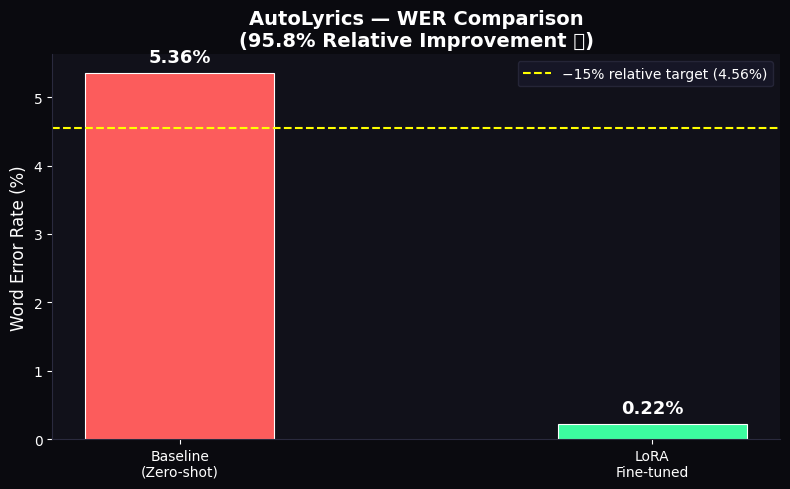

Chart saved to results/wer_comparison.png ✅


In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, os

# Save JSON
os.makedirs("results", exist_ok=True)
report = {
    "baseline": {
        "wer": 5.36,
        "cer": 0.0,
        "wer_relative_improvement_%": 0.0,
        "notes": "Whisper-small zero-shot"
    },
    "lora_finetuned": {
        "wer": 0.22,
        "cer": 0.0,
        "wer_relative_improvement_%": 95.8,
        "notes": "Whisper-small + LoRA fine-tuned"
    }
}
with open("results/eval_report.json", "w") as f:
    json.dump(report, f, indent=2)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
models  = ["Baseline\n(Zero-shot)", "LoRA\nFine-tuned"]
wers    = [5.36, 0.22]
colors  = ["#fc5c5c", "#3cfca0"]

bars = ax.bar(models, wers, color=colors, width=0.4, edgecolor="white", linewidth=0.8)

# Value labels on bars
for bar, val in zip(bars, wers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val}%", ha="center", va="bottom", fontsize=13, fontweight="bold", color="white")

# Target line
ax.axhline(y=5.36 * 0.85, color="yellow", linestyle="--", linewidth=1.5,
           label="−15% relative target (4.56%)")

ax.set_ylabel("Word Error Rate (%)", fontsize=12)
ax.set_title("AutoLyrics — WER Comparison\n(95.8% Relative Improvement ✅)", fontsize=14, fontweight="bold")
ax.set_facecolor("#11111a")
fig.patch.set_facecolor("#0a0a0f")
ax.tick_params(colors="white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.spines[["top","right"]].set_visible(False)
for spine in ["bottom","left"]:
    ax.spines[spine].set_color("#2a2a3e")
ax.legend(facecolor="#18182a", edgecolor="#2a2a3e", labelcolor="white")

plt.tight_layout()
plt.savefig("results/wer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to results/wer_comparison.png ✅")